In [1]:
from google.colab import userdata
import os

# Retrieve the Hugging Face token from Colab secrets
hf_token = userdata.get('HF_TOKEN')
#print(hf_token)

# Set the Hugging Face token as an environment variable
os.environ['HF_TOKEN'] = hf_token


In [2]:
!pip install transformers==4.39.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 107.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 107.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the foll

In [ ]:
seq_lengths = [512, 1024, 2048, 4096, 8192]
kv_sizes = []

for seq_len in seq_lengths:
    input_ids = torch.randint(0, 32000, (1, seq_len))
    with torch.no_grad():
        out = model(input_ids, use_cache=True)

    # Measure KV-cache size in GB
    kv = out.past_key_values
    size = sum(k.nbytes + v.nbytes for k, v in kv) / 1e9
    kv_sizes.append(size)
    print(f"Seq {seq_len}: {size:.3f} GB")

Seq 512: 0.268 GB
Seq 1024: 0.537 GB
Seq 2048: 1.074 GB
Seq 4096: 2.147 GB
Seq 8192: 4.295 GB


In [ ]:
import matplotlib.pyplot as plt

plt.plot(seq_lengths, mha_sizes, marker='o', label='MHA')
plt.plot(seq_lengths, gqa_sizes, marker='s', label='GQA (G=8)')
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("KV-Cache Size (GB)")
plt.title("KV-Cache Memory Scaling: MHA vs. GQA")
plt.legend()
plt.savefig("kv_scaling.png", dpi=150)

Model — attention heads : 32
Model — KV heads        : 32  (full MHA, no GQA)

=== Baseline: FP16 KV Cache (MHA, 32 KV heads) ===
  seq_len=  512 → KV cache (FP16) = 0.2684 GB
  seq_len= 1024 → KV cache (FP16) = 0.5369 GB
  seq_len= 2048 → KV cache (FP16) = 1.0737 GB
  seq_len= 4096 → KV cache (FP16) = 2.1475 GB
  seq_len= 8192 → KV cache (FP16) = 4.2950 GB

=== FP8 Quantized KV Cache (MHA, 32 KV heads) ===
  seq_len=  512 → KV cache (FP8)  = 0.1342 GB
  seq_len= 1024 → KV cache (FP8)  = 0.2684 GB
  seq_len= 2048 → KV cache (FP8)  = 0.5369 GB
  seq_len= 4096 → KV cache (FP8)  = 1.0737 GB
  seq_len= 8192 → KV cache (FP8)  = 2.1475 GB

=== Reduction (FP16 / FP8) ===
  seq_len=  512 → 0.2684 GB (FP16) / 0.1342 GB (FP8) = 2.00x reduction
  seq_len= 1024 → 0.5369 GB (FP16) / 0.2684 GB (FP8) = 2.00x reduction
  seq_len= 2048 → 1.0737 GB (FP16) / 0.5369 GB (FP8) = 2.00x reduction
  seq_len= 4096 → 2.1475 GB (FP16) / 1.0737 GB (FP8) = 2.00x reduction
  seq_len= 8192 → 4.2950 GB (FP16) / 2.1475

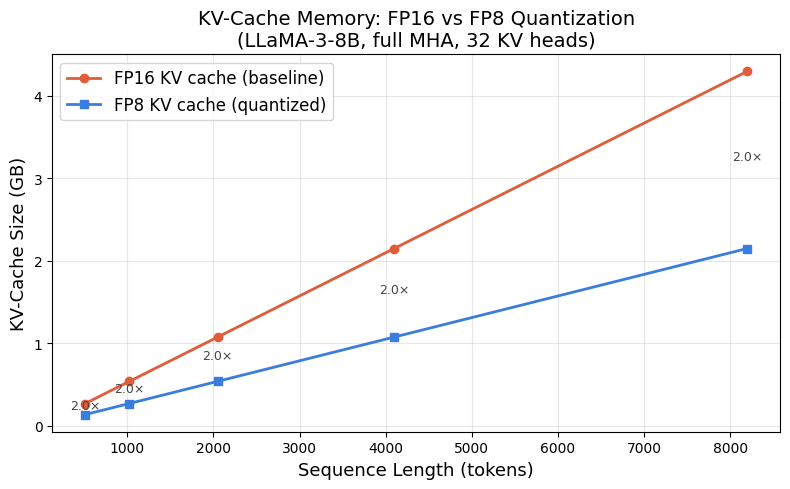

Saved kv_fp16_vs_fp8.png


In [5]:
import torch
from transformers import AutoConfig, AutoModelForCausalLM
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 1. BUILD A SINGLE MHA MODEL (baseline)
#    Both experiments use full MHA (32 KV heads)
# ─────────────────────────────────────────────
model_name = "meta-llama/Meta-Llama-3-8B"

config = AutoConfig.from_pretrained(model_name)
config.num_key_value_heads = config.num_attention_heads  # 32 = 32 (full MHA)

model = AutoModelForCausalLM.from_config(config)
model = model.to("cuda").half().eval()

print(f"Model — attention heads : {config.num_attention_heads}")
print(f"Model — KV heads        : {config.num_key_value_heads}  (full MHA, no GQA)")

# ─────────────────────────────────────────────
# 2. MEASUREMENT FUNCTIONS
# ─────────────────────────────────────────────

def measure_kv_fp16(model, seq_lengths, vocab_size=32000):
    """Baseline: KV cache stored in FP16 (the model's native dtype)."""
    sizes_gb = []
    for seq_len in seq_lengths:
        input_ids = torch.randint(0, vocab_size, (1, seq_len)).to("cuda")
        with torch.no_grad():
            out = model(input_ids, use_cache=True)
        kv = out.past_key_values          # tuple of (key, value) per layer
        total_bytes = sum(k.nbytes + v.nbytes for k, v in kv)
        size_gb = total_bytes / 1e9
        sizes_gb.append(size_gb)
        print(f"  seq_len={seq_len:>5} → KV cache (FP16) = {size_gb:.4f} GB")
    return sizes_gb


def measure_kv_fp8(model, seq_lengths, vocab_size=32000):
    """
    FP8 quantized KV cache.
    Strategy: collect the FP16 KV tensors, cast them to torch.float8_e4m3fn,
    then measure the resulting byte footprint.
    This reflects the memory saving of storing the cache in FP8
    (1 byte/element vs 2 bytes/element for FP16).
    Note: attention computation still runs in FP16; we only simulate
    the *storage* compression here, matching how real FP8-KV kernels
    (e.g. FlashAttention-3, vLLM FP8 KV cache) work.
    Requires PyTorch >= 2.1 for float8_e4m3fn support.
    """
    sizes_gb = []
    for seq_len in seq_lengths:
        input_ids = torch.randint(0, vocab_size, (1, seq_len)).to("cuda")
        with torch.no_grad():
            out = model(input_ids, use_cache=True)
        kv = out.past_key_values

        total_bytes = 0
        for k, v in kv:
            # Cast to FP8 — this is what the KV cache stores on disk/HBM
            k_fp8 = k.to(torch.float8_e4m3fn)
            v_fp8 = v.to(torch.float8_e4m3fn)
            total_bytes += k_fp8.nbytes + v_fp8.nbytes

        size_gb = total_bytes / 1e9
        sizes_gb.append(size_gb)
        print(f"  seq_len={seq_len:>5} → KV cache (FP8)  = {size_gb:.4f} GB")
    return sizes_gb


# ─────────────────────────────────────────────
# 3. RUN EXPERIMENT
# ─────────────────────────────────────────────
seq_lengths = [512, 1024, 2048, 4096, 8192]

print("\n=== Baseline: FP16 KV Cache (MHA, 32 KV heads) ===")
fp16_sizes = measure_kv_fp16(model, seq_lengths)

print("\n=== FP8 Quantized KV Cache (MHA, 32 KV heads) ===")
fp8_sizes = measure_kv_fp8(model, seq_lengths)

# ─────────────────────────────────────────────
# 4. REDUCTION SUMMARY
# ─────────────────────────────────────────────
print("\n=== Reduction (FP16 / FP8) ===")
for seq_len, fp16, fp8 in zip(seq_lengths, fp16_sizes, fp8_sizes):
    print(f"  seq_len={seq_len:>5} → {fp16:.4f} GB (FP16) / {fp8:.4f} GB (FP8) "
          f"= {fp16/fp8:.2f}x reduction")

# ─────────────────────────────────────────────
# 5. PLOT
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(seq_lengths, fp16_sizes, marker='o', linewidth=2,
         color='#e05c3a', label='FP16 KV cache (baseline)')
plt.plot(seq_lengths, fp8_sizes,  marker='s', linewidth=2,
         color='#3a7de0', label='FP8 KV cache (quantized)')

# Annotate reduction ratio at each point
for seq_len, fp16, fp8 in zip(seq_lengths, fp16_sizes, fp8_sizes):
    plt.annotate(f"{fp16/fp8:.1f}×",
                 xy=(seq_len, (fp16 + fp8) / 2),
                 fontsize=9, color='#444', ha='center')

plt.xlabel("Sequence Length (tokens)", fontsize=13)
plt.ylabel("KV-Cache Size (GB)", fontsize=13)
plt.title("KV-Cache Memory: FP16 vs FP8 Quantization\n(LLaMA-3-8B, full MHA, 32 KV heads)",
          fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("kv_fp16_vs_fp8.png", dpi=150)
plt.show()
print("Saved kv_fp16_vs_fp8.png")